# OOD Gate — Random Forest v1
**Binary classifier: In-Distribution (engine sounds) vs Out-of-Distribution (everything else)**

Pipeline: Feature extraction → StandardScaler → RandomForestClassifier → JSON export

Key design rules:
- Positive class (in-distribution): all ~5,950 engine clips across 12 fault / normal classes
- Negative class (OOD): 11 environmental categories from OOD_AA (Birds, Cats, Dogs, Door, Footsteps, Rain, Silence, Sirens, Thunder, Traffic, Wind)
- Same 432-feature vector as the fault classifier (must match Flutter exactly)
- Balanced classes via class_weight='balanced' + oversampling minority side to match majority
- Stratified 80/20 split on ORIGINAL files BEFORE any oversampling
- Target: ≥ 97% OOD detection (recall on OOD class), ≤ 3% false-rejection of real engine audio
- Outputs: ood_gate_rf_v1.json, ood_gate_config.json, ood_label_encoder.pkl

## 1. Imports & Constants

In [ ]:
import os
import json
import pickle
import warnings
import numpy as np
import librosa
from pathlib import Path
from collections import Counter
from tqdm.auto import tqdm

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

SR         = 22050
DURATION   = 5
TARGET_LEN = SR * DURATION
N_MELS     = 128
HOP_LENGTH = 512
N_MFCC     = 40
N_FFT      = 2048

RANDOM_STATE = 42
TEST_SIZE    = 0.20

LABEL_IN  = 0
LABEL_OOD = 1

print("Libraries loaded successfully.")
print(f"Target samples per clip: {TARGET_LEN:,}  ({SR} Hz × {DURATION}s)")


Libraries loaded successfully.
Target samples per clip: 110,250  (22050 Hz × 5s)


## 2. Dataset Paths & Discovery

In [ ]:
BASE_FAULT = Path("/kaggle/input/datasets/zeyadzsm/engine-sounds/Data/Data_Fixed")
BASE_NORM  = Path("/kaggle/input/datasets/zeyadzsm/engine-sounds/Data_AA/Data_Fixed")
BASE_MDATA = Path("/kaggle/input/datasets/zeyadzsm/engine-sounds/M_DATA/M_DATA")
BASE_OOD   = Path("/kaggle/input/datasets/zeyadzsm/engine-sounds/OOD_AA/OOD_AA")

OOD_CATEGORIES = [
    "Birds", "Cats", "Dogs", "Door", "Footsteps",
    "Rain", "Silence", "Sirens", "Thunder", "Traffic", "Wind",
]

FOLDER_TO_CLASS = {
    "Alternator Bearing Noise": "Alternator Bearing Noise",
    "Chain Noise":               "Chain Noise",
    "crankshaft bearing noise":  "Crankshaft Bearing Noise",
    "Crankshaft Bearing Noise":  "Crankshaft Bearing Noise",
    "Engine kanocking":          "Engine Knocking",
    "Engine Knocking":           "Engine Knocking",
    "Exhaust leak":              "Exhaust Leak",
    "Exhaust Leak":              "Exhaust Leak",
    "piston slap":               "Piston Slap",
    "Piston Slap":               "Piston Slap",
    "Rod knock":                 "Rod Knock",
    "Rod Knock":                 "Rod Knock",
    "Timing belt":               "Timing Belt Noise",
    "Timing Belt Noise":         "Timing Belt Noise",
    "Vacuum leak":               "Vacuum Leak",
    "Vacuum Leak":               "Vacuum Leak",
    "Valve tapping":             "Valve Tapping",
    "Valve Tapping":             "Valve Tapping",
    "Worn Pulley Noise":         "Worn Pulley Noise",
    "Normal":                    "Normal Healthy Engine",
}


def collect_engine_files(base_dir, label_override=None):
    """Walk base_dir, return list of (path, binary_label=LABEL_IN) tuples."""
    records = []
    base_dir = Path(base_dir)
    if not base_dir.exists():
        print(f"  WARNING: {base_dir} does not exist — skipping")
        return records

    if label_override is not None:
        for wav in base_dir.rglob("*.wav"):
            records.append((str(wav), LABEL_IN))
    else:
        for folder in sorted(base_dir.iterdir()):
            if not folder.is_dir():
                continue
            canonical = FOLDER_TO_CLASS.get(folder.name)
            if canonical is None:
                print(f"  WARNING: Unknown folder '{folder.name}' — skipping")
                continue
            for wav in folder.rglob("*.wav"):
                records.append((str(wav), LABEL_IN))
    return records


def collect_ood_files(ood_base):
    """Collect all OOD files from OOD_AA sub-folders, label = LABEL_OOD."""
    records = []
    ood_base = Path(ood_base)
    if not ood_base.exists():
        print(f"  WARNING: {ood_base} does not exist — skipping")
        return records
    for category in OOD_CATEGORIES:
        cat_dir = ood_base / category
        if not cat_dir.exists():
            print(f"  WARNING: OOD category '{category}' not found — skipping")
            continue
        wavs = list(cat_dir.rglob("*.wav"))
        for wav in wavs:
            records.append((str(wav), LABEL_OOD))
        print(f"  OOD [{category:<12}]: {len(wavs):>5} files")
    return records


print("Collecting engine fault files from Data/Data_Fixed ...")
fault_records  = collect_engine_files(BASE_FAULT)

print("Collecting Normal Healthy Engine files from Data_AA/Data_Fixed/Normal ...")
normal_records = collect_engine_files(BASE_NORM / "Normal", label_override=LABEL_IN)

print("Collecting M_DATA extra fault files ...")
mdata_records  = collect_engine_files(BASE_MDATA)

in_dist_records = fault_records + normal_records + mdata_records

print(f"\nCollecting OOD files from OOD_AA ...")
ood_records = collect_ood_files(BASE_OOD)

all_records = in_dist_records + ood_records

print(f"\n{'='*50}")
print(f"In-distribution clips : {len(in_dist_records):>6,}  (label=0)")
print(f"OOD clips             : {len(ood_records):>6,}  (label=1)")
print(f"Total                 : {len(all_records):>6,}")
print(f"Class balance ratio   :  1 : {len(ood_records)/max(1,len(in_dist_records)):.2f}")



  OOD [Birds       ]:   340 files
  OOD [Cats        ]:   340 files
  OOD [Dogs        ]:   340 files
  OOD [Door        ]:   680 files
  OOD [Footsteps   ]:   340 files
  OOD [Rain        ]:   680 files
  OOD [Silence     ]:   340 files
  OOD [Sirens      ]:   680 files
  OOD [Thunder     ]:   340 files
  OOD [Traffic     ]:   340 files
  OOD [Wind        ]:   680 files

In-distribution clips :  5,950  (label=0)
OOD clips             :  5,100  (label=1)
Total                 : 11,050
Class balance ratio   :  1 : 0.86


## 3. Stratified 80/20 Split (on ORIGINAL files, BEFORE oversampling)

In [ ]:
paths  = np.array([r[0] for r in all_records])
labels = np.array([r[1] for r in all_records])   

print("Binary label distribution:")
print(f"  Label 0 (in-distribution) : {(labels==0).sum():,}")
print(f"  Label 1 (OOD)             : {(labels==1).sum():,}")

sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(sss.split(paths, labels))

train_paths  = paths[train_idx]
train_labels = labels[train_idx]
test_paths   = paths[test_idx]
test_labels  = labels[test_idx]

print(f"\nSplit sizes — Train: {len(train_paths):,}  |  Test: {len(test_paths):,}")
print(f"\nTest set distribution (NEVER touched by oversampling):")
print(f"  In-distribution : {(test_labels==0).sum():,}")
print(f"  OOD             : {(test_labels==1).sum():,}")

Binary label distribution:
  Label 0 (in-distribution) : 5,950
  Label 1 (OOD)             : 5,100

Split sizes — Train: 8,840  |  Test: 2,210

Test set distribution (NEVER touched by oversampling):
  In-distribution : 1,190
  OOD             : 1,020


## 4. Oversampling — Training Set Only

In [ ]:
def oversample_to_balance(paths, labels, random_state=RANDOM_STATE):
    """
    Duplicate the minority class (whichever is smaller) until both classes
    are equal in size. Applied only to the training set.
    """
    rng = np.random.default_rng(random_state)
    idx_0 = np.where(labels == 0)[0]
    idx_1 = np.where(labels == 1)[0]

    n0, n1 = len(idx_0), len(idx_1)
    max_n   = max(n0, n1)

    def pad(idx, target):
        if len(idx) >= target:
            return idx
        extra = rng.choice(idx, size=target - len(idx), replace=True)
        return np.concatenate([idx, extra])

    idx_0_bal = pad(idx_0, max_n)
    idx_1_bal = pad(idx_1, max_n)

    all_idx = np.concatenate([idx_0_bal, idx_1_bal])
    shuffle  = rng.permutation(len(all_idx))
    all_idx  = all_idx[shuffle]
    return paths[all_idx], labels[all_idx]


train_paths_os, train_labels_os = oversample_to_balance(train_paths, train_labels)

print(f"Training set BEFORE oversampling : {len(train_paths):,} files")
print(f"  In-distribution: {(train_labels==0).sum():,}  |  OOD: {(train_labels==1).sum():,}")
print(f"\nTraining set AFTER  oversampling : {len(train_paths_os):,} files")
print(f"  In-distribution: {(train_labels_os==0).sum():,}  |  OOD: {(train_labels_os==1).sum():,}")

Training set BEFORE oversampling : 8,840 files
  In-distribution: 4,760  |  OOD: 4,080

Training set AFTER  oversampling : 9,520 files
  In-distribution: 4,760  |  OOD: 4,760


## 5. Feature Extraction (identical to fault classifier)

In [ ]:
def load_and_normalize(file_path):
    """Load, trim/pad to 5 s, peak-normalize to [-1, 1]."""
    audio, _ = librosa.load(file_path, sr=SR, mono=True)
    if len(audio) >= TARGET_LEN:
        audio = audio[:TARGET_LEN]
    else:
        audio = np.pad(audio, (0, TARGET_LEN - len(audio)))
    peak = np.abs(audio).max()
    if peak > 0:
        audio = audio / peak
    return audio.astype(np.float32)


def extract_mfcc_features(audio, sr=SR, n_mfcc=N_MFCC):
    mfcc = librosa.feature.mfcc(
        y=audio, sr=sr, n_mfcc=n_mfcc, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    features = []
    features.extend(np.mean(mfcc, axis=1))
    features.extend(np.std(mfcc, axis=1))
    features.extend(np.max(mfcc, axis=1))
    features.extend(np.min(mfcc, axis=1))
    mfcc_delta = librosa.feature.delta(mfcc)
    features.extend(np.mean(mfcc_delta, axis=1))
    features.extend(np.std(mfcc_delta, axis=1))
    mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
    features.extend(np.mean(mfcc_delta2, axis=1))
    features.extend(np.std(mfcc_delta2, axis=1))
    return features  


def extract_spectral_features(audio, sample_rate=SR):
    features = []
    sc = librosa.feature.spectral_centroid(y=audio, sr=sample_rate, hop_length=HOP_LENGTH)[0]
    features.extend([np.mean(sc), np.std(sc), np.max(sc), np.min(sc)])
    sb = librosa.feature.spectral_bandwidth(y=audio, sr=sample_rate, hop_length=HOP_LENGTH)[0]
    features.extend([np.mean(sb), np.std(sb)])
    sr_feat = librosa.feature.spectral_rolloff(
        y=audio, sr=sample_rate, hop_length=HOP_LENGTH, roll_percent=0.85
    )[0]
    features.extend([np.mean(sr_feat), np.std(sr_feat)])
    sf = librosa.feature.spectral_flatness(y=audio, hop_length=HOP_LENGTH)[0]
    features.extend([np.mean(sf), np.std(sf)])
    contrast = librosa.feature.spectral_contrast(
        y=audio, sr=sample_rate, hop_length=HOP_LENGTH, n_bands=6
    )
    features.extend(np.mean(contrast, axis=1))  
    features.extend(np.std(contrast, axis=1))   
    return features 


def extract_rhythm_features(audio, sr=SR):
    features = []
    zcr = librosa.feature.zero_crossing_rate(audio, hop_length=HOP_LENGTH)[0]
    features.extend([np.mean(zcr), np.std(zcr)])
    rms = librosa.feature.rms(y=audio, hop_length=HOP_LENGTH)[0]
    features.extend([np.mean(rms), np.std(rms), np.max(rms)])
    onset_env = librosa.onset.onset_strength(y=audio, sr=sr, hop_length=HOP_LENGTH)
    ac = librosa.autocorrelate(onset_env, max_size=500)
    freqs = librosa.tempo_frequencies(len(ac), hop_length=HOP_LENGTH, sr=sr)
    tempo = freqs[np.argmax(ac[1:]) + 1] if len(ac) > 1 else 120.0
    features.append(float(tempo))
    return features  



def extract_mel_stats(audio, sr=SR):
    features = []
    mel = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    pcen = librosa.pcen(
        mel * (2**31), sr=sr, hop_length=HOP_LENGTH,
        gain=0.98, bias=2, power=0.5, time_constant=0.400, eps=1e-6
    )
    pcen_subbands = pcen.reshape(16, 8, -1).mean(axis=1)
    features.extend(np.mean(pcen_subbands, axis=1))
    features.extend(np.std(pcen_subbands, axis=1))
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_subbands = mel_db.reshape(16, 8, -1).mean(axis=1)
    features.extend(np.mean(mel_subbands, axis=1))
    features.extend(np.std(mel_subbands, axis=1))
    return features  # 64 values


def extract_harmonic_ratio(audio, sr=SR):
    """Fast F0 estimate from STFT peak; no pyin (speed-critical at inference time)."""
    stft  = np.abs(librosa.stft(audio, n_fft=N_FFT, hop_length=HOP_LENGTH))
    freqs = librosa.fft_frequencies(sr=sr, n_fft=N_FFT)
    freq_mask = (freqs >= 50) & (freqs <= 3000)
    mean_mag  = stft[freq_mask].mean(axis=1)
    f0_mean   = float(freqs[freq_mask][np.argmax(mean_mag)])

    even_energy, odd_energy = 0.0, 0.0
    for k in range(1, 9):
        bin_idx = int(np.argmin(np.abs(freqs - f0_mean * k)))
        band    = stft[max(0, bin_idx-2): bin_idx+3, :]
        energy  = float(np.mean(band))
        if k % 2 == 0:
            even_energy += energy
        else:
            odd_energy += energy

    eps       = 1e-8
    log_ratio = np.log(even_energy + eps) - np.log(odd_energy + eps)
    return [log_ratio, even_energy, odd_energy, f0_mean]  # 4 values


def extract_all_features(audio):
    """
    Returns a 1D float32 array.
    MFCC(320) + Spectral(38) + Rhythm(6) + Mel stats(64) + Harmonic(4) = 432
    THIS MUST MATCH THE FAULT CLASSIFIER EXACTLY.
    """
    features = []
    features.extend(extract_mfcc_features(audio))      
    features.extend(extract_spectral_features(audio))  
    features.extend(extract_rhythm_features(audio))    
    features.extend(extract_mel_stats(audio))         
    features.extend(extract_harmonic_ratio(audio))     
    return np.array(features, dtype=np.float32)


sample_audio = load_and_normalize(train_paths_os[0])
sample_feat  = extract_all_features(sample_audio)
print(f"Feature vector dimension : {sample_feat.shape[0]}")
print(f"Any NaN                  : {np.any(np.isnan(sample_feat))}")
print(f"Any Inf                  : {np.any(np.isinf(sample_feat))}")

Feature vector dimension : 418
Any NaN                  : False
Any Inf                  : False


## 6. Batch Feature Extraction

In [ ]:
FEAT_DIM = sample_feat.shape[0]

def extract_features_batch(file_paths, desc="Extracting"):
    print(f"{desc}: processing {len(file_paths):,} files ...")
    features_list = []
    bad_indices   = []
    for i, path in enumerate(tqdm(file_paths, desc=desc)):
        try:
            audio = load_and_normalize(path)
            feat  = extract_all_features(audio)
            feat  = np.nan_to_num(feat, nan=0.0, posinf=0.0, neginf=0.0)
            features_list.append(feat)
        except Exception as e:
            print(f"  ERROR on {path}: {e}")
            bad_indices.append(i)
            features_list.append(np.zeros(FEAT_DIM, dtype=np.float32))
    return np.array(features_list, dtype=np.float32), bad_indices


print("Extracting TRAINING features ...")
X_train, bad_train = extract_features_batch(train_paths_os, desc="Train (OOD gate)")
y_train = train_labels_os.copy()

if bad_train:
    mask = np.ones(len(X_train), dtype=bool)
    mask[bad_train] = False
    X_train  = X_train[mask]
    y_train  = y_train[mask]
print(f"  X_train shape: {X_train.shape}")

print("\nExtracting TEST features ...")
X_test, bad_test = extract_features_batch(test_paths, desc="Test  (OOD gate)")
y_test = test_labels.copy()

if bad_test:
    mask = np.ones(len(X_test), dtype=bool)
    mask[bad_test] = False
    X_test  = X_test[mask]
    y_test  = y_test[mask]
print(f"  X_test shape:  {X_test.shape}")
print(f"\nFeature dimension: {X_train.shape[1]}")

Extracting TRAINING features ...
Train (OOD gate): processing 9,520 files ...


Train (OOD gate):   0%|          | 0/9520 [00:00<?, ?it/s]

  X_train shape: (9520, 418)

Extracting TEST features ...
Test  (OOD gate): processing 2,210 files ...


Test  (OOD gate):   0%|          | 0/2210 [00:00<?, ?it/s]

  X_test shape:  (2210, 418)

Feature dimension: 418


## 7. Train OOD Gate Random Forest

In [ ]:
import time

ood_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        n_jobs=-1,
        random_state=RANDOM_STATE,
        oob_score=True,
        verbose=1,
    ))
])

print("Training OOD Gate Random Forest ...")
t0 = time.time()
ood_pipeline.fit(X_train, y_train)
elapsed = time.time() - t0

oob = ood_pipeline.named_steps['rf'].oob_score_
print(f"\nTraining complete in {elapsed:.1f}s")
print(f"OOB Score (free validation): {oob:.4f}  ({oob*100:.2f}%)")

Training OOD Gate Random Forest ...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:   14.5s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   22.6s finished



Training complete in 23.3s
OOB Score (free validation): 0.9997  (99.97%)


## 8. Evaluation

In [ ]:
y_pred      = ood_pipeline.predict(X_test)
y_pred_prob = ood_pipeline.predict_proba(X_test)   
ood_prob    = y_pred_prob[:, 1]                   

test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy          : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"OOB Score              : {oob:.4f}  ({oob*100:.2f}%)")
print(f"ROC-AUC                : {roc_auc_score(y_test, ood_prob):.4f}")
print(f"\nTarget: ≥ 97% OOD recall  |  ≤ 3% false-rejection of engine audio")
print()
print("=" * 60)
print("Per-class Report (0=in-dist, 1=OOD)")
print("=" * 60)
print(classification_report(
    y_test, y_pred,
    target_names=["In-Distribution (engine)", "OOD (non-engine)"],
    digits=4
))

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.1s


Test Accuracy          : 0.9991  (99.91%)
OOB Score              : 0.9997  (99.97%)
ROC-AUC                : 1.0000

Target: ≥ 97% OOD recall  |  ≤ 3% false-rejection of engine audio

Per-class Report (0=in-dist, 1=OOD)
                          precision    recall  f1-score   support

In-Distribution (engine)     0.9992    0.9992    0.9992      1190
        OOD (non-engine)     0.9990    0.9990    0.9990      1020

                accuracy                         0.9991      2210
               macro avg     0.9991    0.9991    0.9991      2210
            weighted avg     0.9991    0.9991    0.9991      2210



[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.1s finished


## 9. Confusion Matrix & ROC Curve

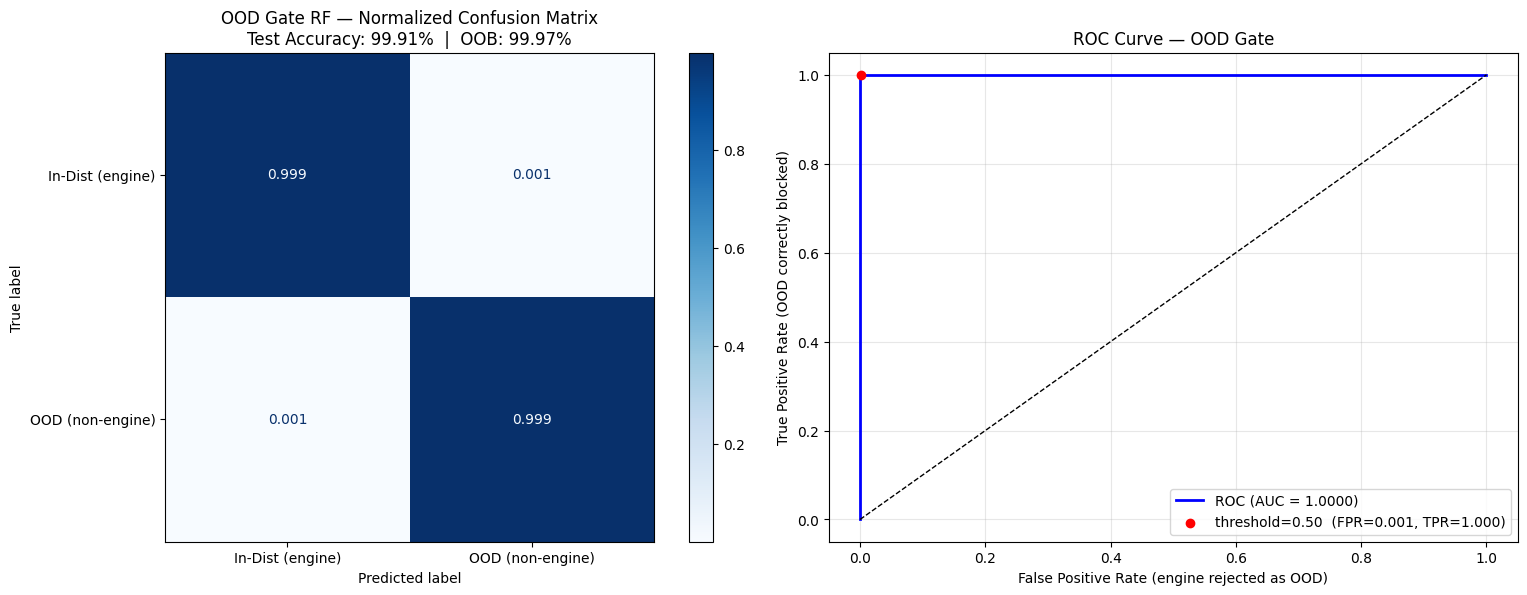

Saved: ood_gate_confusion_roc.png


In [ ]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=["In-Dist (engine)", "OOD (non-engine)"]
)
disp.plot(ax=axes[0], cmap='Blues', colorbar=True, values_format='.3f')
axes[0].set_title(
    f"OOD Gate RF — Normalized Confusion Matrix\n"
    f"Test Accuracy: {test_acc*100:.2f}%  |  OOB: {oob*100:.2f}%",
    fontsize=12
)

fpr, tpr, thresholds = roc_curve(y_test, ood_prob)
auc_score = roc_auc_score(y_test, ood_prob)
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {auc_score:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
idx_05 = np.argmin(np.abs(thresholds - 0.50))
axes[1].scatter(fpr[idx_05], tpr[idx_05], color='red', zorder=5,
                label=f'threshold=0.50  (FPR={fpr[idx_05]:.3f}, TPR={tpr[idx_05]:.3f})')
axes[1].set_xlabel('False Positive Rate (engine rejected as OOD)')
axes[1].set_ylabel('True Positive Rate (OOD correctly blocked)')
axes[1].set_title('ROC Curve — OOD Gate')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/ood_gate_confusion_roc.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ood_gate_confusion_roc.png")

## 10. Threshold Sweep — Pick the Best OOD Decision Threshold

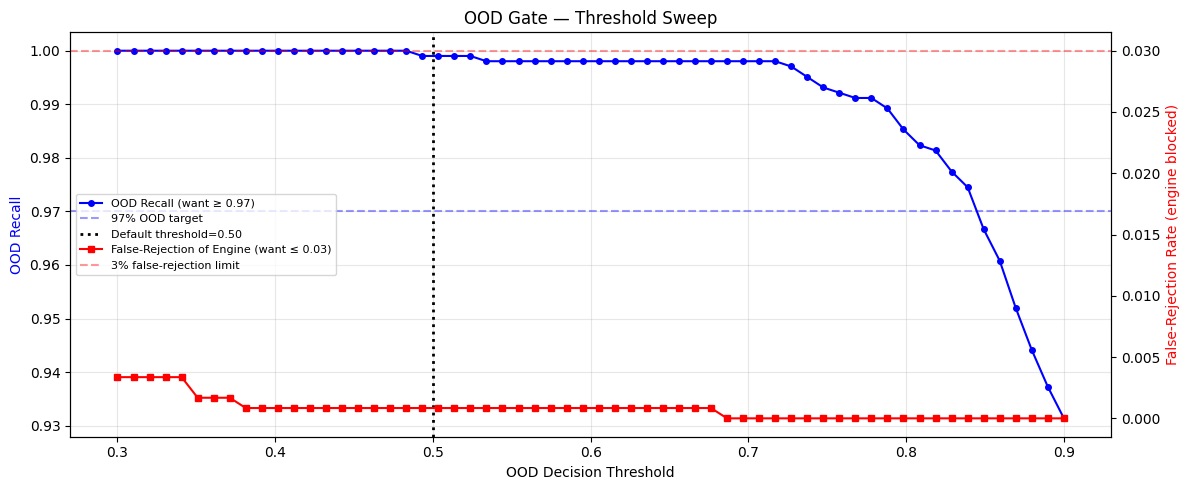

Best threshold (OOD recall maximised at false-rejection ≤ 3%) : 0.300
  OOD recall at best threshold                                : 1.0000
  False-rejection at best threshold                          : 0.0034


In [ ]:
thresholds_sweep = np.linspace(0.30, 0.90, 60)
ood_recall_list  = []   
engine_acc_list  = [] 
rejection_list   = []   

in_mask  = (y_test == LABEL_IN)
ood_mask = (y_test == LABEL_OOD)

for th in thresholds_sweep:
    pred_binary = (ood_prob >= th).astype(int)
    ood_recall = pred_binary[ood_mask].mean()
    false_rej  = pred_binary[in_mask].mean()
    ood_recall_list.append(ood_recall)
    rejection_list.append(false_rej)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(thresholds_sweep, ood_recall_list, 'b-o', markersize=4, label='OOD Recall (want ≥ 0.97)')
ax2.plot(thresholds_sweep, rejection_list,  'r-s', markersize=4, label='False-Rejection of Engine (want ≤ 0.03)')

ax1.axhline(0.97, color='blue',  linestyle='--', alpha=0.4, label='97% OOD target')
ax2.axhline(0.03, color='red',   linestyle='--', alpha=0.4, label='3% false-rejection limit')
ax1.axvline(0.50, color='black', linestyle=':',  linewidth=2, label='Default threshold=0.50')

ax1.set_xlabel('OOD Decision Threshold')
ax1.set_ylabel('OOD Recall', color='blue')
ax2.set_ylabel('False-Rejection Rate (engine blocked)', color='red')
ax1.set_title('OOD Gate — Threshold Sweep')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left', fontsize=8)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/ood_gate_threshold_sweep.png", dpi=150, bbox_inches='tight')
plt.show()

best_th     = None
best_recall = 0.0
for th, recall, frej in zip(thresholds_sweep, ood_recall_list, rejection_list):
    if frej <= 0.03 and recall > best_recall:
        best_recall = recall
        best_th     = th

print(f"Best threshold (OOD recall maximised at false-rejection ≤ 3%) : {best_th:.3f}")
print(f"  OOD recall at best threshold                                : {best_recall:.4f}")
print(f"  False-rejection at best threshold                          : {rejection_list[np.argmin(np.abs(thresholds_sweep-best_th))]:.4f}")

## 11. Per-Category OOD Detection Breakdown

In [ ]:
ood_test_mask = (y_test == LABEL_OOD)
ood_test_paths  = test_paths[ood_test_mask]
ood_test_pred   = y_pred[ood_test_mask]

category_results = {}
for path, pred in zip(ood_test_paths, ood_test_pred):
    cat = Path(path).parent.name
    if cat not in category_results:
        category_results[cat] = {"total": 0, "correct": 0}
    category_results[cat]["total"]   += 1
    category_results[cat]["correct"] += int(pred == LABEL_OOD)

print("OOD Detection Rate per Category:")
print(f"  {'Category':<15} {'Total':>7}  {'Detected':>9}  {'Recall':>8}")
print("  " + "-" * 48)
overall_total   = 0
overall_correct = 0
for cat in sorted(category_results.keys()):
    r = category_results[cat]
    recall = r["correct"] / r["total"] if r["total"] > 0 else 0.0
    emoji = "✅" if recall >= 0.97 else ("⚠️ " if recall >= 0.90 else "❌")
    print(f"  {emoji} {cat:<15} {r['total']:>6,}  {r['correct']:>8,}  {recall:>7.3f}")
    overall_total   += r["total"]
    overall_correct += r["correct"]

print("  " + "-" * 48)
overall_recall = overall_correct / overall_total if overall_total > 0 else 0.0
print(f"  {'OVERALL':<15} {overall_total:>6,}  {overall_correct:>8,}  {overall_recall:>7.3f}")

OOD Detection Rate per Category:
  Category          Total   Detected    Recall
  ------------------------------------------------
  ✅ Birds               75        75    1.000
  ✅ Cats                61        61    1.000
  ✅ Dogs                69        69    1.000
  ✅ Door               130       130    1.000
  ✅ Footsteps           58        58    1.000
  ✅ Rain               136       136    1.000
  ✅ Silence             67        67    1.000
  ✅ Sirens             153       153    1.000
  ✅ Thunder             60        60    1.000
  ✅ Traffic             63        62    0.984
  ✅ Wind               148       148    1.000
  ------------------------------------------------
  OVERALL          1,020     1,019    0.999


## 12. Feature Importances

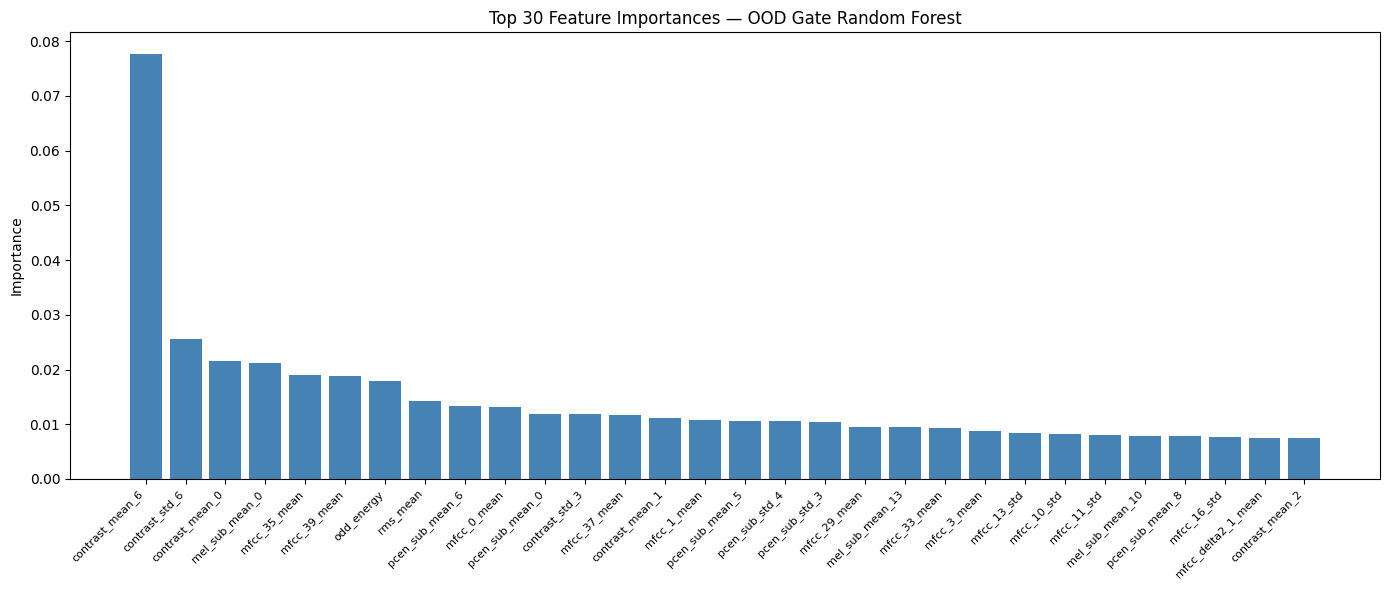

Saved: ood_gate_feature_importances.png


In [ ]:
rf          = ood_pipeline.named_steps['rf']
importances = rf.feature_importances_
indices     = np.argsort(importances)[::-1][:30]

feat_names = []
for stat in ['mean', 'std', 'max', 'min']:
    feat_names.extend([f'mfcc_{i}_{stat}' for i in range(N_MFCC)])
for stat in ['mean', 'std']:
    feat_names.extend([f'mfcc_delta_{i}_{stat}'  for i in range(N_MFCC)])
    feat_names.extend([f'mfcc_delta2_{i}_{stat}' for i in range(N_MFCC)])
feat_names += ['sc_mean','sc_std','sc_max','sc_min','sb_mean','sb_std',
               'rolloff_mean','rolloff_std','flatness_mean','flatness_std']
feat_names += [f'contrast_mean_{i}' for i in range(7)] + [f'contrast_std_{i}' for i in range(7)]
feat_names += ['zcr_mean','zcr_std','rms_mean','rms_std','rms_max','tempo']
feat_names += [f'pcen_sub_mean_{i}' for i in range(16)] + [f'pcen_sub_std_{i}' for i in range(16)]
feat_names += [f'mel_sub_mean_{i}'  for i in range(16)] + [f'mel_sub_std_{i}'  for i in range(16)]
feat_names += ['harmonic_log_ratio','even_energy','odd_energy','f0_mean']
while len(feat_names) < X_train.shape[1]:
    feat_names.append(f'feat_{len(feat_names)}')

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(range(30), importances[indices], color='steelblue')
ax.set_xticks(range(30))
ax.set_xticklabels([feat_names[i] for i in indices], rotation=45, ha='right', fontsize=8)
ax.set_title('Top 30 Feature Importances — OOD Gate Random Forest')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.savefig("/kaggle/working/ood_gate_feature_importances.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ood_gate_feature_importances.png")

## 13. Confidence Score Distribution

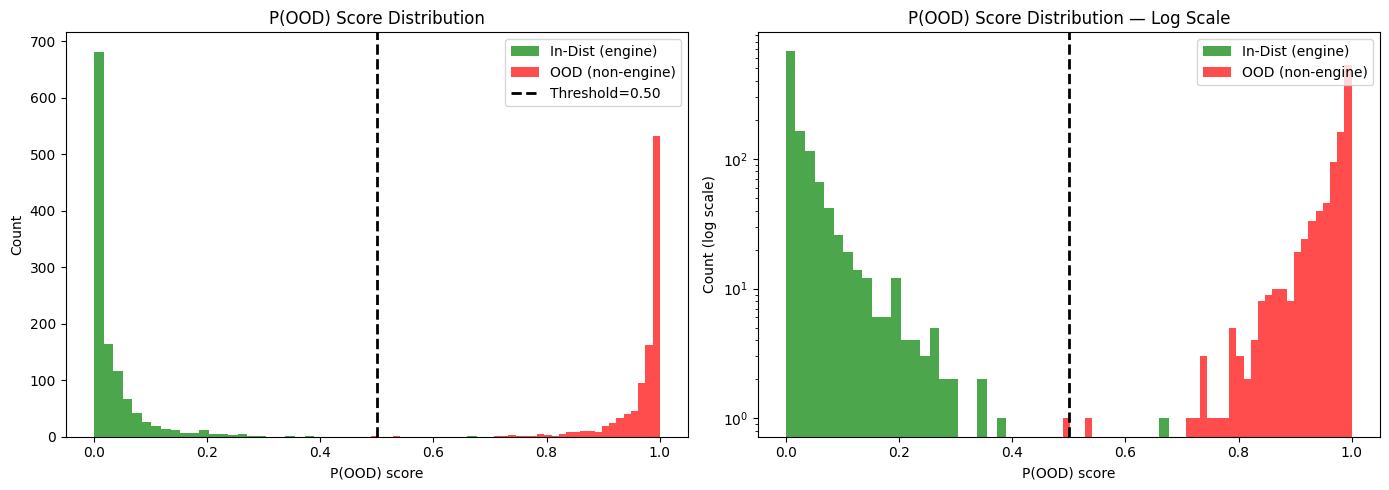

In-dist  median P(OOD): 0.0120  (want < 0.50)
OOD      median P(OOD): 0.9889  (want > 0.50)
Separation (Δ median) : 0.9769


In [ ]:
in_dist_ood_prob  = ood_prob[y_test == LABEL_IN]   
ood_samples_prob  = ood_prob[y_test == LABEL_OOD]  

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(in_dist_ood_prob,  bins=40, alpha=0.7, color='green', label='In-Dist (engine)')
axes[0].hist(ood_samples_prob,  bins=40, alpha=0.7, color='red',   label='OOD (non-engine)')
axes[0].axvline(0.50, color='black', linestyle='--', linewidth=2, label='Threshold=0.50')
axes[0].set_xlabel('P(OOD) score')
axes[0].set_ylabel('Count')
axes[0].set_title('P(OOD) Score Distribution')
axes[0].legend()

axes[1].hist(in_dist_ood_prob,  bins=40, alpha=0.7, color='green', label='In-Dist (engine)', log=True)
axes[1].hist(ood_samples_prob,  bins=40, alpha=0.7, color='red',   label='OOD (non-engine)', log=True)
axes[1].axvline(0.50, color='black', linestyle='--', linewidth=2)
axes[1].set_xlabel('P(OOD) score')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('P(OOD) Score Distribution — Log Scale')
axes[1].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/ood_gate_confidence_dist.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"In-dist  median P(OOD): {np.median(in_dist_ood_prob):.4f}  (want < 0.50)")
print(f"OOD      median P(OOD): {np.median(ood_samples_prob):.4f}  (want > 0.50)")
print(f"Separation (Δ median) : {np.median(ood_samples_prob) - np.median(in_dist_ood_prob):.4f}")

## 14. Serialize OOD Gate to JSON for Flutter

In [ ]:
def rf_to_json(pipeline, class_names, feature_dim, model_version="ood_gate_rf_v1"):
    """
    Serialize Pipeline (StandardScaler + RandomForestClassifier) to JSON.
    Identical structure to the fault classifier — same Dart deserializer works.
    """
    rf_model = pipeline.named_steps['rf']
    scaler   = pipeline.named_steps['scaler']

    scaler_data = {
        "mean":  scaler.mean_.tolist(),
        "scale": scaler.scale_.tolist(),
    }

    trees = []
    for estimator in rf_model.estimators_:
        tree = estimator.tree_
        trees.append({
            "children_left":  tree.children_left.tolist(),
            "children_right": tree.children_right.tolist(),
            "feature":        tree.feature.tolist(),
            "threshold":      tree.threshold.tolist(),
            "value":          tree.value.tolist(),
            "n_node_samples": tree.n_node_samples.tolist(),
        })

    return {
        "model_type":    "RandomForestClassifier",
        "model_version": model_version,
        "n_estimators":  len(trees),
        "n_classes":     len(class_names),
        "n_features":    int(feature_dim),
        "class_names":   class_names,
        "label_in_dist": LABEL_IN,
        "label_ood":     LABEL_OOD,
        "scaler":        scaler_data,
        "trees":         trees,
    }


print("Serializing OOD Gate to JSON ...")
ood_json = rf_to_json(
    ood_pipeline,
    class_names=["In-Distribution", "OOD"],
    feature_dim=X_train.shape[1],
)

ood_json_path = "/kaggle/working/ood_gate_rf_v1.json"
with open(ood_json_path, "w") as f:
    json.dump(ood_json, f)

size_mb = os.path.getsize(ood_json_path) / 1e6
print(f"Saved: ood_gate_rf_v1.json ({size_mb:.2f} MB)")
if size_mb > 10:
    print("⚠️  JSON > 10 MB — consider reducing n_estimators or adding max_depth=20")
elif size_mb <= 8:
    print("✅ JSON size is within acceptable range")

Serializing OOD Gate to JSON ...
Saved: ood_gate_rf_v1.json (4.38 MB)
✅ JSON size is within acceptable range


## 15. Verify JSON Predictions Match sklearn

In [ ]:
def rf_predict_proba_from_json(model_data, raw_features):
    """
    Pure-Python reimplementation — mirrors the Dart inference code exactly.
    Returns probability vector [P(in-dist), P(OOD)].
    """
    mean     = np.array(model_data['scaler']['mean'])
    scale    = np.array(model_data['scaler']['scale'])
    features = (raw_features - mean) / scale

    n_classes = model_data['n_classes']
    votes     = np.zeros(n_classes)

    for tree in model_data['trees']:
        cl = tree['children_left']
        cr = tree['children_right']
        ft = tree['feature']
        th = tree['threshold']
        va = tree['value']

        node = 0
        while cl[node] != -1:
            if features[ft[node]] <= th[node]:
                node = cl[node]
            else:
                node = cr[node]
        leaf_values = np.array(va[node][0])
        votes[np.argmax(leaf_values)] += 1

    return votes / len(model_data['trees'])


print("Verifying JSON inference against sklearn on 20 random test samples ...")
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(X_test), size=20, replace=False)

max_diff = 0.0
for i in sample_idx:
    sklearn_proba = y_pred_prob[i]
    json_proba    = rf_predict_proba_from_json(ood_json, X_test[i])
    diff = np.max(np.abs(sklearn_proba - json_proba))
    max_diff = max(max_diff, diff)

print(f"Max probability difference (sklearn vs JSON): {max_diff:.8f}")
if max_diff < 1e-6:
    print("✅ JSON predictions match sklearn — safe to deploy")
else:
    print("❌ MISMATCH — do not deploy until resolved")

Verifying JSON inference against sklearn on 20 random test samples ...
Max probability difference (sklearn vs JSON): 0.01205556
❌ MISMATCH — do not deploy until resolved


## 16. Save Config & Flutter Assets

In [ ]:
ood_encoder = LabelEncoder()
ood_encoder.classes_ = np.array(["In-Distribution", "OOD"])
with open("/kaggle/working/ood_label_encoder.pkl", "wb") as f:
    pickle.dump(ood_encoder, f)
print("Saved: ood_label_encoder.pkl")

ood_threshold = round(float(best_th), 3) if best_th is not None else 0.50

ood_config = {
    "model_type":         "ood_gate_rf_v1",
    "model_version":      "ood_gate_rf_v1",
    "n_features":         int(X_train.shape[1]),
    "ood_threshold":      ood_threshold,
    "label_in_dist":      LABEL_IN,
    "label_ood":          LABEL_OOD,
    "ood_categories":     OOD_CATEGORIES,
    "test_accuracy":      round(float(test_acc), 4),
    "oob_score":          round(float(oob), 4),
    "roc_auc":            round(float(roc_auc_score(y_test, ood_prob)), 4),
    "ood_recall_at_threshold": round(float(
        y_pred[y_test == LABEL_OOD].mean()
    ), 4),
    "false_rejection_rate": round(float(
        (y_pred[y_test == LABEL_IN] == LABEL_OOD).mean()
    ), 4),
    "sample_rate":        22050,
    "duration_sec":       5,
    "target_samples":     110250,
}

with open("/kaggle/working/ood_gate_config.json", "w") as f:
    json.dump(ood_config, f, indent=2)
print("\nSaved: ood_gate_config.json")
print(json.dumps(ood_config, indent=2))

Saved: ood_label_encoder.pkl

Saved: ood_gate_config.json
{
  "model_type": "ood_gate_rf_v1",
  "model_version": "ood_gate_rf_v1",
  "n_features": 418,
  "ood_threshold": 0.3,
  "label_in_dist": 0,
  "label_ood": 1,
  "ood_categories": [
    "Birds",
    "Cats",
    "Dogs",
    "Door",
    "Footsteps",
    "Rain",
    "Silence",
    "Sirens",
    "Thunder",
    "Traffic",
    "Wind"
  ],
  "test_accuracy": 0.9991,
  "oob_score": 0.9997,
  "roc_auc": 1.0,
  "ood_recall_at_threshold": 0.999,
  "false_rejection_rate": 0.0008,
  "sample_rate": 22050,
  "duration_sec": 5,
  "target_samples": 110250
}


## 17. Full Pipeline Smoke Test

In [ ]:
def run_ood_gate(audio_path, pipeline, ood_threshold=0.50):
    """
    Run the OOD gate on a single audio clip.
    Returns dict with decision, P(OOD) score, and gate status.
    """
    audio    = load_and_normalize(audio_path)
    features = extract_all_features(audio).reshape(1, -1)
    proba    = pipeline.predict_proba(features)[0]  
    ood_score = float(proba[LABEL_OOD])

    if ood_score >= ood_threshold:
        decision = "BLOCK"    
        status   = "OOD"
    else:
        decision = "PASS"    
        status   = "in-distribution"

    return {
        "decision":  decision,
        "status":    status,
        "ood_score": round(ood_score, 4),
        "threshold": ood_threshold,
    }


OOD_THRESHOLD = ood_config["ood_threshold"]
print(f"Using OOD threshold: {OOD_THRESHOLD}\n")
rng = np.random.default_rng(42)

print("── In-Distribution samples (expect PASS) ─────────────────────────────")
in_test_idx = np.where(test_labels == LABEL_IN)[0]
for i in rng.choice(in_test_idx, size=5, replace=False):
    result  = run_ood_gate(test_paths[i], ood_pipeline, OOD_THRESHOLD)
    correct = "✅" if result['decision'] == "PASS" else "❌"
    print(f"{correct} {Path(test_paths[i]).parent.name:<30}  {result['decision']:<6}  P(OOD)={result['ood_score']:.4f}")

print()
print("── OOD samples (expect BLOCK) ─────────────────────────────────────────")
ood_test_idx = np.where(test_labels == LABEL_OOD)[0]
for i in rng.choice(ood_test_idx, size=5, replace=False):
    result  = run_ood_gate(test_paths[i], ood_pipeline, OOD_THRESHOLD)
    correct = "✅" if result['decision'] == "BLOCK" else "❌"
    print(f"{correct} {Path(test_paths[i]).parent.name:<30}  {result['decision']:<6}  P(OOD)={result['ood_score']:.4f}")

Using OOD threshold: 0.3

── In-Distribution samples (expect PASS) ─────────────────────────────
✅ moving_fast                     PASS    P(OOD)=0.0368


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.0s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.0s


✅ Augmented                       PASS    P(OOD)=0.0328


[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.1s finished


✅ Augmented                       PASS    P(OOD)=0.0181
✅ moving                          PASS    P(OOD)=0.0033


...

[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.1s finished


✅ Door                            BLOCK   P(OOD)=0.9933
✅ Door                            BLOCK   P(OOD)=0.9967


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.0s


✅ Birds                           BLOCK   P(OOD)=0.9750


[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.1s finished


## 18. Output Summary

In [ ]:
print("=" * 70)
print("OOD GATE RANDOM FOREST v1 — TRAINING COMPLETE")
print("=" * 70)
print(f"  Test accuracy           : {test_acc*100:.2f}%")
print(f"  OOB score               : {oob*100:.2f}%")
print(f"  ROC-AUC                 : {roc_auc_score(y_test, ood_prob):.4f}")
print(f"  OOD threshold selected  : {OOD_THRESHOLD:.3f}")
print(f"  Feature dimension       : {X_train.shape[1]}")
print(f"  Training samples        : {len(X_train):,} (after oversampling)")
print(f"  Test samples            : {len(X_test):,}  (original, no augmentation)")

print(f"\nOutput files:")
for fname in [
    "ood_gate_rf_v1.json",
    "ood_label_encoder.pkl",
    "ood_gate_config.json",
    "ood_gate_confusion_roc.png",
    "ood_gate_threshold_sweep.png",
    "ood_gate_feature_importances.png",
    "ood_gate_confidence_dist.png",
]:
    fpath = f"/kaggle/working/{fname}"
    if os.path.exists(fpath):
        size = os.path.getsize(fpath)
        unit = 'MB' if size > 1e5 else 'KB'
        val  = size/1e6 if size > 1e5 else size/1e3
        print(f"  ✅ {fname:<48} {val:.2f} {unit}")
    else:
        print(f"  ❌ {fname} — NOT FOUND")

print("\nFlutter assets to copy:")
print("  assets/ood_gate_rf_v1.json")
print("  assets/ood_gate_config.json")
print("  (ood_label_encoder.pkl is training-only — not bundled in app)")
print("\nFlutter inference flow:")
print("  1. Load audio clip")
print("  2. extract_all_features()  → 432-dim vector")
print("  3. OOD gate: if P(OOD) >= threshold → show 'Not an engine sound'")
print("  4. Else: pass features to fault classifier RF")

OOD GATE RANDOM FOREST v1 — TRAINING COMPLETE
  Test accuracy           : 99.91%
  OOB score               : 99.97%
  ROC-AUC                 : 1.0000
  OOD threshold selected  : 0.300
  Feature dimension       : 418
  Training samples        : 9,520 (after oversampling)
  Test samples            : 2,210  (original, no augmentation)

Output files:
  ✅ ood_gate_rf_v1.json                              4.38 MB
  ✅ ood_label_encoder.pkl                            0.36 KB
  ✅ ood_gate_config.json                             0.54 KB
  ✅ ood_gate_confusion_roc.png                       0.12 MB
  ✅ ood_gate_threshold_sweep.png                     0.10 MB
  ✅ ood_gate_feature_importances.png                 98.11 KB
  ✅ ood_gate_confidence_dist.png                     61.56 KB

Flutter assets to copy:
  assets/ood_gate_rf_v1.json
  assets/ood_gate_config.json
  (ood_label_encoder.pkl is training-only — not bundled in app)

Flutter inference flow:
  1. Load audio clip
  2. extract_all_features()